# Rg ― Radius of Gyration

Consider how the sizes of particles with different shapes can be compared. $R_g$ can be used for that purpose.

$R_g$ is computed (defined) as follows:

* compute the center of mass (or density)
* compute the weighted average of squared deviation from the center
* compute the square root of the above avarage

Using the known formula for $R_g$, the next code computes Rg's of several ellipsoids with different lenghts of semi-axes, $a$, $b$ and $c$.

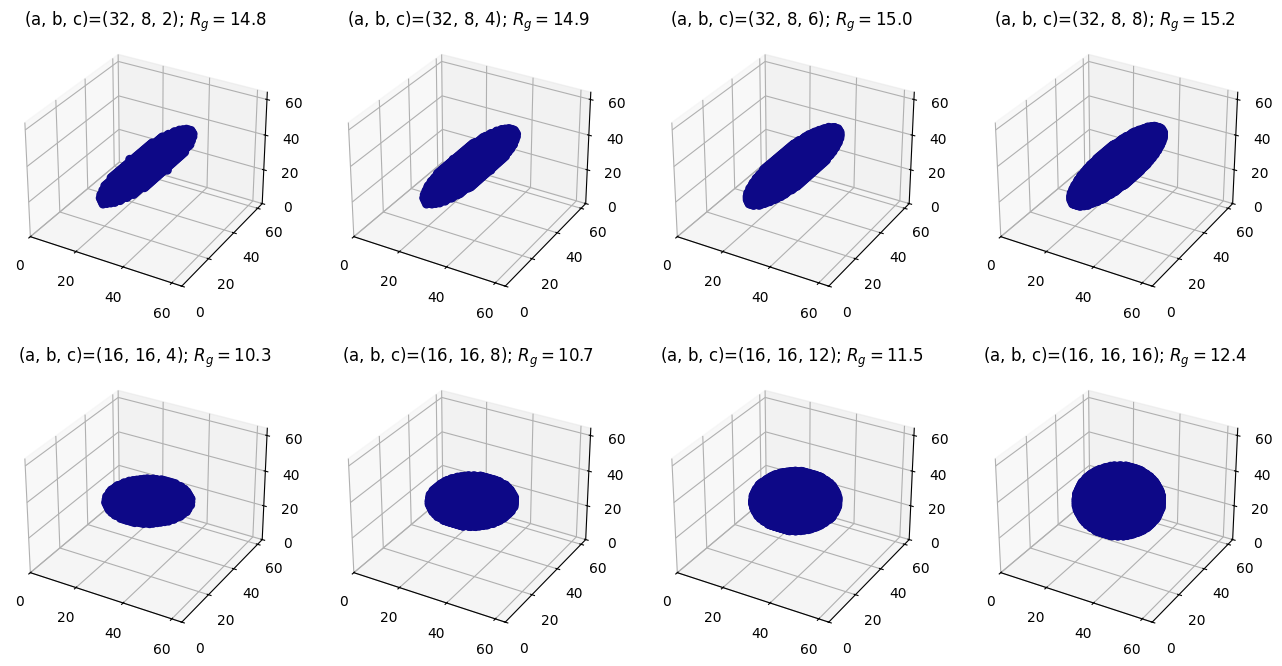

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from molass.Shapes import Ellipsoid
from molass.DensitySpace import VoxelSpace
from molass.SAXS.Simulator import compute_saxs, draw_saxs

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8), subplot_kw=dict(projection='3d'))

for i in range(2):
    for j in range(4):
        ax = axes[i, j]
        a = 16 * (2 - i)
        b = 8 * (i + 1)
        c = 2 * ((i + 1)*(j + 1))
        rg = np.sqrt((a**2 + b**2 + c**2)/5)
        ax.set_title(f'(a, b, c)={(a, b, c)}; $R_g={rg:.1f}$')
        ellipsoid = Ellipsoid(a, b, c)
        space = VoxelSpace(64, ellipsoid)
        space.plot_as_dots(ax)

In the above plot, the shapes are defined with uniform density, meaning the density is uniformly one throughout each shape.
The next plot illustrates this fact more clearly.

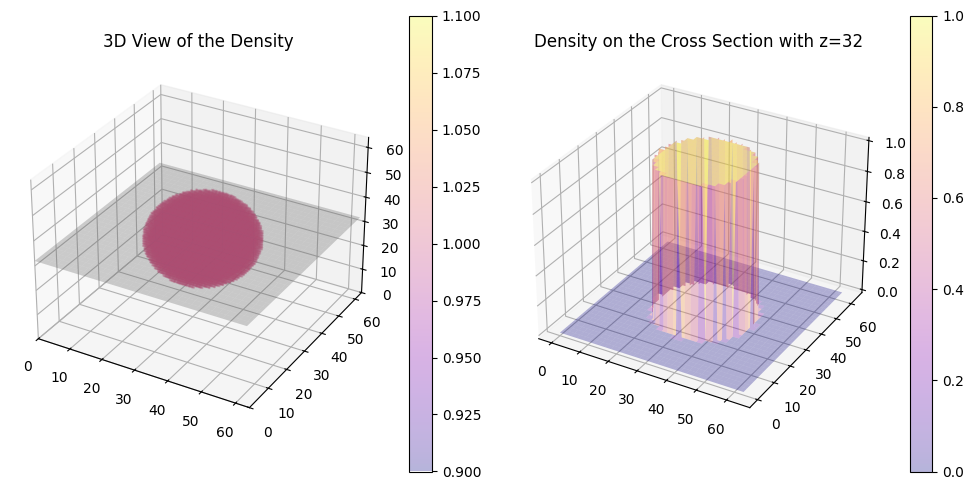

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from molass.Shapes import Ellipsoid
from molass.DensitySpace import VoxelSpace

fig, axes = plt.subplots(ncols=2, figsize=(10,5), subplot_kw=dict(projection='3d'))
a, b, c = 16, 16, 16
ellipsoid = Ellipsoid(a, b, c)
space = VoxelSpace(64, ellipsoid)
space.plot_with_density(axes)
fig.tight_layout()

Next method computes $R_g$ without using the formula, namely by computing the square root of the weighted average of the squared deviations from the center.

In [3]:
space.compute_rg()

np.float64(12.373697563931419)

Confirm the concept with another plot that depicts a sphere with a Gaussian (non-uniform) density distribution.

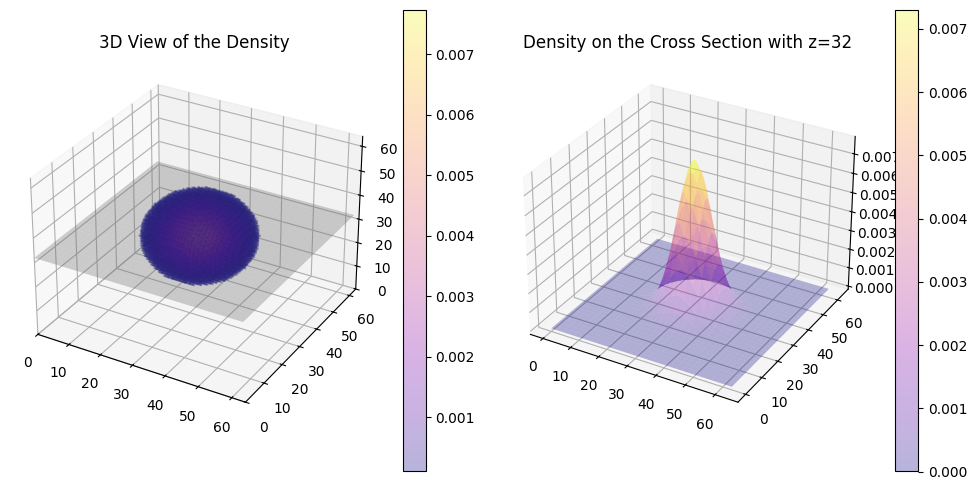

In [4]:
from molass.DensitySpace import VoxelSpace
from molass.DensitySpace.Densities import gaussian_density_for_demo
fig, axes = plt.subplots(ncols=2, figsize=(10,5), subplot_kw=dict(projection='3d'))

N = 64
density = gaussian_density_for_demo(N)
space = VoxelSpace(N, density=density)
space.plot_with_density(axes)
fig.tight_layout()

Compare this $R_g$ with the previous result.

In [5]:
space.compute_rg()

np.float64(9.486832051163836)